In [1]:
!pip install -q pandas numpy scikit-learn sentence-transformers bertopic keybert pymorphy3 natasha wordcloud plotly umap-learn hdbscan

In [2]:
import re
import numpy as np
import pandas as pd

In [3]:
from sentence_transformers import SentenceTransformer
from keybert import KeyBERT

from sklearn.feature_extraction.text import CountVectorizer

import plotly.express as px

from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [4]:
from bertopic import BERTopic

In [5]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Устройство:", device)

Устройство: cuda


In [6]:
df = pd.read_csv("/content/school_vacancies.csv")

print(df.shape)

df.head()

(2215, 55)


,id,stateRegionCode,vacancyName,codeProfession,codeProfessionalSphere,professionalSphereName,vacancyAddress,vacancyAddressHouse,geo,salary,...,positionRequirements,contactList,salaryMin,salaryMax,qualifications,responsibilities,addressCode,workPlace,trainingDays,shift
0,eeaddde8-f5d0-11f0-ba7d-9959eb3311ba,3100000000000,Уборщик территорий,192624.0,Education,"Образование, наука","Белгородская область, Город Губкин, Мичурина у...",дом: ЗД. 21;,"{""latitude"": 51.28298, ""longitude"": 37.529349}",от 27100,...,"Добросовестность, ответственность","[{""contactType"": ""Телефон"", ""contactValue"": ""+...",27100.0,27100.0,"Добросовестность, ответственность",Уборка прилегающей территории,3.100000e+16,"{""workPlaceForeign"": false, ""workPlaceOrdinary...",0.0,[]
1,74fb9f78-f533-11f0-a027-0dd543315e5a,5200000000000,помощник распределителя работ,177874.0,Industry,Производство,"Нижегородская область, Город Нижний Новгород, ...",дом: Д.5;,"{""latitude"": 56.250627, ""longitude"": 43.976396}",от 28000,...,"дисциплинированность, ответственность","[{""contactType"": ""Телефон"", ""contactValue"": ""+...",28000.0,35000.0,"дисциплинированность, ответственность",Внесение информации в информационные базы данных,5.200000e+16,"{""workPlaceForeign"": false, ""workPlaceOrdinary...",0.0,[]
2,0bb2daf0-e166-11f0-a6fd-690b9f9d74c0,5200000000000,Гардеробщик,116334.0,Culture,"Искусство, культура и развлечения","Нижегородская область, Город Дзержинск, Ленина...",дом: 62;,"{""latitude"": 56.237197, ""longitude"": 43.456541}",от 27093,...,квотируемое рабочее место для молодёжи моложе ...,"[{""contactType"": ""Телефон"", ""contactValue"": ""+...",27093.0,27093.0,квотируемое рабочее место для молодёжи моложе ...,прием и выдача верхней одежды,5.200000e+16,"{""workPlaceForeign"": false, ""workPlaceOrdinary...",0.0,[]
3,4297f4e9-f68a-11f0-a027-0dd543315e5a,5200000000000,уборщик служебных помещений,192588.0,Education,"Образование, наука","Нижегородская область, Город Выкса, Братьев Ба...",дом: ЗД. 3;,"{""latitude"": 55.320565, ""longitude"": 42.151576}",от 27903,...,дисциплинированность,"[{""contactType"": ""Телефон"", ""contactValue"": ""+...",27903.0,27903.0,дисциплинированность,Убитрать служебные помещения,5.200001e+16,"{""workPlaceForeign"": false, ""workPlaceOrdinary...",0.0,[]
4,07e57c50-f6bc-11f0-8628-a3cca5294b78,6800000000000,Подсобный рабочий,167711.0,Industry,Производство,"Тамбовская область, Мордовский район, Промышле...",строение 1,"{""latitude"": 52.133137, ""longitude"": 40.824028}",от 28571,...,Ответственность. Несовершеннолетние от 14 до 1...,"[{""contactType"": ""Телефон"", ""contactValue"": ""+...",28571.0,28571.0,Ответственность. Несовершеннолетние от 14 до 1...,"Уборка территории, выполнение мелких ремонтных...",6.800900e+16,"{""workPlaceForeign"": false, ""workPlaceOrdinary...",0.0,[]


In [7]:
text_columns = [
    "vacancyName",
    "responsibilities",
    "positionRequirements",
    "qualifications"
]

for col in text_columns:
    df[col] = df[col].fillna("")

df["text"] = (
    df["vacancyName"] + " " +
    df["responsibilities"] + " " +
    df["positionRequirements"] + " " +
    df["qualifications"]
)

In [8]:
def clean_text(text):

    text = str(text).lower()

    text = re.sub(r"http\S+", " ", text)
    text = re.sub(r"\d+", " ", text)

    text = re.sub(r"[^а-яёa-z\s]", " ", text)

    text = re.sub(r"\s+", " ", text)

    return text.strip()


df["clean_text"] = df["text"].apply(clean_text)

In [9]:
model = SentenceTransformer(
    "intfloat/multilingual-e5-base",
    device=device
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [10]:
embeddings = model.encode(
    df["clean_text"].tolist(),
    batch_size=128,
    show_progress_bar=True,
    convert_to_numpy=True
)

Batches:   0%|          | 0/18 [00:00<?, ?it/s]

In [11]:
kw_model = KeyBERT(model)

keywords = []

for text in df["clean_text"]:

    kw = kw_model.extract_keywords(
        text,
        keyphrase_ngram_range=(1, 3),
        stop_words=None,
        top_n=10
    )

    keywords.extend([k[0] for k in kw])

In [12]:
keyword_df = pd.Series(keywords)

top_keywords = (
    keyword_df
    .value_counts()
    .head(30)
    .reset_index()
)

top_keywords.columns = ["keyword", "count"]

top_keywords

,keyword,count
0,подсобный рабочий,284
1,уборщик производственных служебных,275
2,уборщик производственных,233
3,уборщик,229
4,служебных помещений уборка,151
5,уборщик служебных помещений,148
6,уборщик служебных,130
7,дисциплинированность,129
8,дисциплинированность ответственность,111
9,помещений уборка,106


In [13]:
fig = px.bar(
    top_keywords,
    x="count",
    y="keyword",
    orientation="h",
    title="Самые частые требования работодателей"
)

fig.update_layout(yaxis={"categoryorder": "total ascending"})

fig.show()

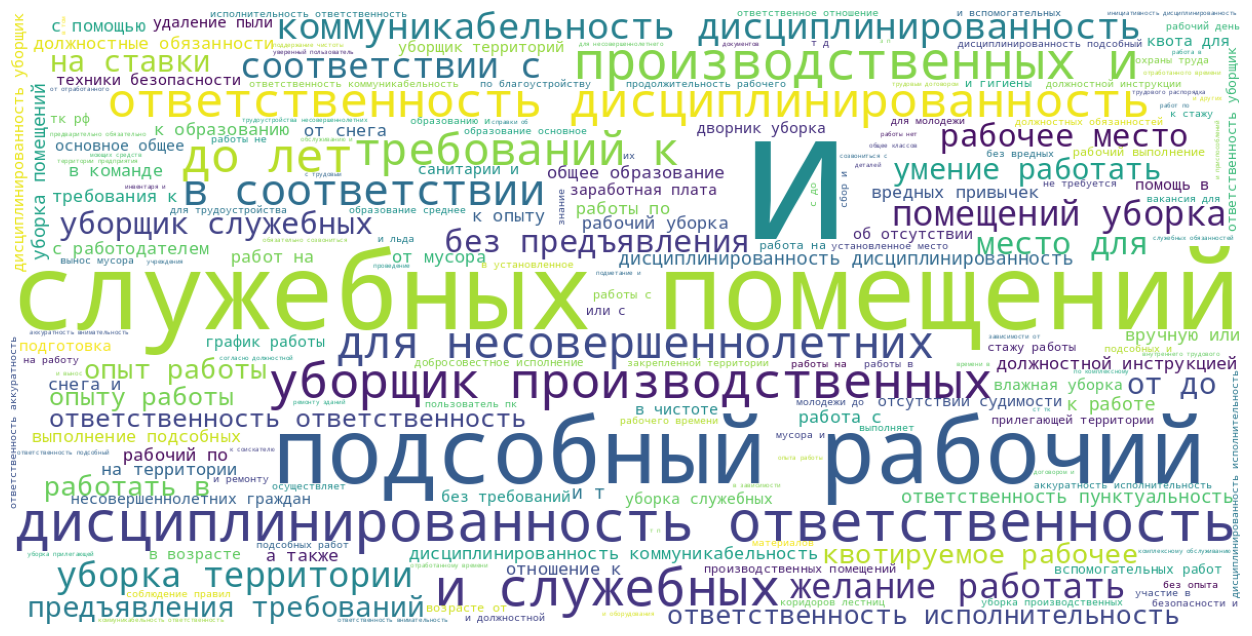

In [14]:
all_text = " ".join(df["clean_text"])

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate(all_text)

plt.figure(figsize=(16, 8))

plt.imshow(wordcloud)

plt.axis("off")

plt.show()

In [15]:
topic_model = BERTopic(
    language="multilingual",
    calculate_probabilities=True,
    verbose=True
)

topics, probs = topic_model.fit_transform(
    df["clean_text"],
    embeddings
)

2026-06-22 18:10:44,385 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-06-22 18:11:08,211 - BERTopic - Dimensionality - Completed ✓
2026-06-22 18:11:08,212 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-22 18:11:08,516 - BERTopic - Cluster - Completed ✓
2026-06-22 18:11:08,521 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-06-22 18:11:08,640 - BERTopic - Representation - Completed ✓


In [16]:
df["topic"] = topics

df[["vacancyName", "topic"]].head()

,vacancyName,topic
0,Уборщик территорий,39
1,помощник распределителя работ,36
2,Гардеробщик,2
3,уборщик служебных помещений,0
4,Подсобный рабочий,27


In [17]:
topic_info = topic_model.get_topic_info()

topic_info.head(20)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,473,-1_по_работы_ответственность_на,"[по, работы, ответственность, на, дисциплиниро...",[подсобный рабочий выполнение подсобных и вспо...
1,0,301,0_помещений_служебных_уборщик_производственных,"[помещений, служебных, уборщик, производственн...",[уборщик производственных и служебных помещени...
2,1,112,1_подсобный_рабочий_ответственность_дисциплини...,"[подсобный, рабочий, ответственность, дисципли...",[подсобный рабочий подсобные работы на террито...
3,2,101,2_до_лет_несовершеннолетних_для,"[до, лет, несовершеннолетних, для, рабочее, кв...",[уборщик производственных и служебных помещени...
4,3,74,3_пк_документов_word_знание,"[пк, документов, word, знание, excel, office, ...",[оформитель технической документации разряда в...
5,4,61,4_грузов_перемещение_подсобный_рабочий,"[грузов, перемещение, подсобный, рабочий, рабо...",[подсобный рабочий погрузка разгрузка перемеще...
6,5,59,5_дворник_территории_закрепленной_снега,"[дворник, территории, закрепленной, снега, мус...",[дворник ежедневно очищает урны от мусора и пе...
7,6,47,6_дворник_территории_уборка_трудолюбие,"[дворник, территории, уборка, трудолюбие, дисц...",[дворник уборка территории дисциплинированност...
8,7,46,7_моющих_правила_средств_безопасности,"[моющих, правила, средств, безопасности, помещ...",[санитарка размещает материальные объекты и ме...
9,8,44,8_снега_территории_тротуаров_территорий,"[снега, территории, тротуаров, территорий, от,...",[уборщик территории уборка территории от мусор...


In [18]:
topic_model.visualize_barchart()

In [19]:
topic_model.visualize_topics()